# When does MettleQ's Apple GPU path actually win?

This experiment asks a deliberately narrow question: for the **same exact
statevector workload on one Apple M3 Pro**, when is the SDK's fastest CPU path
faster, and when is MettleQ's Apple GPU path faster?

It also checks every returned amplitude. Timing without correctness is not a
useful simulator benchmark.

## Learning goals

After this notebook you should be able to:

1. distinguish a complete SDK-call benchmark from an isolated-kernel timing;
2. understand why Qiskit Aer MPS is not automatically the fastest choice;
3. read a CPU/GPU crossover chart without treating it as universal; and
4. interpret `exact_match=False` separately from numerical correctness.

## Fair comparison contract

Each framework runs the same depth-three circuit at 16–29 qubits. The circuit
contains single-qubit rotations, nearest-neighbour entanglement, and one layer
of long-range mirror CNOTs.

- **Qiskit CPU:** Aer statevector and, through 22 qubits, Aer MPS; the faster
  measured method is selected per width.
- **PennyLane CPU:** `lightning.qubit` with complex128.
- **MettleQ:** exact statevector forced onto the Apple GPU through each SDK
  adapter.
- **Output:** the complete analytic statevector, not shots or one observable.
- **Timing:** one warm-up and three measured complete calls; transpilation is
  excluded, result materialization is included.
- **Accuracy:** global-phase-aligned maximum amplitude error must be at most
  `5e-6`.

In [1]:
from pathlib import Path
import json
from IPython.display import HTML, Image, display

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parents[1]

RUN = ROOT / "assets/benchmarks-frozen/fork-m3pro-20260718-sdk-crossover-radix16-idle"
payload = json.loads((RUN / "results.json").read_text())
print("Machine:", payload["machine"])
print("Versions:", payload["environment"])
print("Protocol:", payload["protocol"])

Machine: arm64
Versions: {'mettleq': '0.2.0', 'mlx': '0.32.0', 'numpy': '2.4.6', 'pennylane': '0.45.1', 'pennylane-lightning': '0.45.0', 'qiskit': '2.5.0', 'qiskit-aer': '0.17.2'}
Protocol: {'accuracy_atol': 5e-06, 'depth': 3, 'max_qiskit_mps_width': 22, 'memory_safety': {'maximum_validation_fraction': 0.5, 'minimum_system_headroom_gib': 6.0, 'mlx_memory_limit_fraction': 0.5}, 'output_contract': 'complete analytic statevector', 'qiskit_aer_enable_truncation': False, 'repeats': 3, 'timing_scope': 'compiled complete SDK execution and full-state return; transpilation excluded', 'warmups': 1, 'widths': [16, 18, 20, 22, 24, 26, 27, 28, 29, 30]}


## Inspect the raw measurements

The ratio is CPU time divided by MettleQ GPU time. A value above 1 means
MettleQ is faster; a value below 1 means the CPU reference is faster. Keeping
the raw milliseconds prevents a ratio from hiding very small or very large
absolute runtimes.

In [2]:
rows = []
for record in payload["records"]:
    q = record["qiskit"]
    p = record["pennylane"]
    rows.append({
        "qubits": record["width"],
        "Aer fastest method": q["cpu_fastest_method"],
        "Aer CPU ms": q["cpu_fastest_ms"],
        "MettleQ via Qiskit ms": q["mettleq_gpu_ms"],
        "Aer / MettleQ": q["cpu_over_mettleq"],
        "Qiskit max error": q["max_amplitude_error"],
        "Lightning CPU ms": p["cpu_ms"],
        "MettleQ via PennyLane ms": p["mettleq_gpu_ms"],
        "Lightning / MettleQ": p["cpu_over_mettleq"],
        "PennyLane max error": p["max_amplitude_error"],
    })

headers = list(rows[0])
def formatted(key, value):
    if key.endswith("max error"):
        return f"{value:.2e}"
    if key.endswith("MettleQ"):
        return f"{value:.3f}x"
    if key.endswith("ms"):
        return f"{value:.3f}"
    return str(value)

table = ["<table><thead><tr>"]
table.extend(f"<th>{header}</th>" for header in headers)
table.append("</tr></thead><tbody>")
for row in rows:
    table.append("<tr>")
    table.extend(f"<td>{formatted(header, row[header])}</td>" for header in headers)
    table.append("</tr>")
table.append("</tbody></table>")
display(HTML("".join(table)))

qubits,Aer fastest method,Aer CPU ms,MettleQ via Qiskit ms,Aer / MettleQ,Qiskit max error,Lightning CPU ms,MettleQ via PennyLane ms,Lightning / MettleQ,PennyLane max error
16,statevector,3.760,14.728,0.255x,3.75e-07,9.003,6.233,1.445x,3.49e-07
18,statevector,12.608,20.119,0.627x,3.98e-07,46.538,12.543,3.710x,3.96e-07
20,statevector,47.574,35.859,1.327x,4.02e-07,118.461,10.675,11.097x,3.03e-07
22,statevector,138.076,43.700,3.160x,1.47e-07,470.725,28.653,16.429x,3.35e-07
24,statevector,687.554,150.980,4.554x,1.99e-07,2027.497,108.346,18.713x,1.63e-07
26,statevector,2257.433,530.395,4.256x,2.60e-07,8360.268,434.765,19.229x,7.52e-08
27,statevector,3954.558,1110.417,3.561x,2.21e-07,17369.838,955.118,18.186x,1.41e-07
28,statevector,5833.566,2059.440,2.833x,8.59e-08,35927.705,1696.528,21.177x,1.22e-07
29,statevector,14252.833,5203.575,2.739x,1.33e-07,74375.386,4646.928,16.005x,1.20e-07


## Accuracy gate first

Statevectors may differ by a physically irrelevant global phase, so the
benchmark aligns that phase before comparing amplitudes. The following cell is
the pass/fail gate; the timing plot should not be interpreted if it fails.

In [3]:
ATOL = payload["protocol"]["accuracy_atol"]
worst_error = max(
    max(row["Qiskit max error"], row["PennyLane max error"])
    for row in rows
)
assert worst_error <= ATOL, (worst_error, ATOL)
print(f"PASS: worst full-state error {worst_error:.2e} <= {ATOL:.2e}")
print(f"The worst row used {worst_error / ATOL:.1%} of the allowed tolerance.")

PASS: worst full-state error 4.02e-07 <= 5.00e-06
The worst row used 8.0% of the allowed tolerance.


## The crossover plot

The top row shows absolute time on a logarithmic scale. The bottom row shows
speedup, with the dashed 1.0 line marking equality. This makes it visible both
*where* the crossover occurs and *how expensive* each state size is.

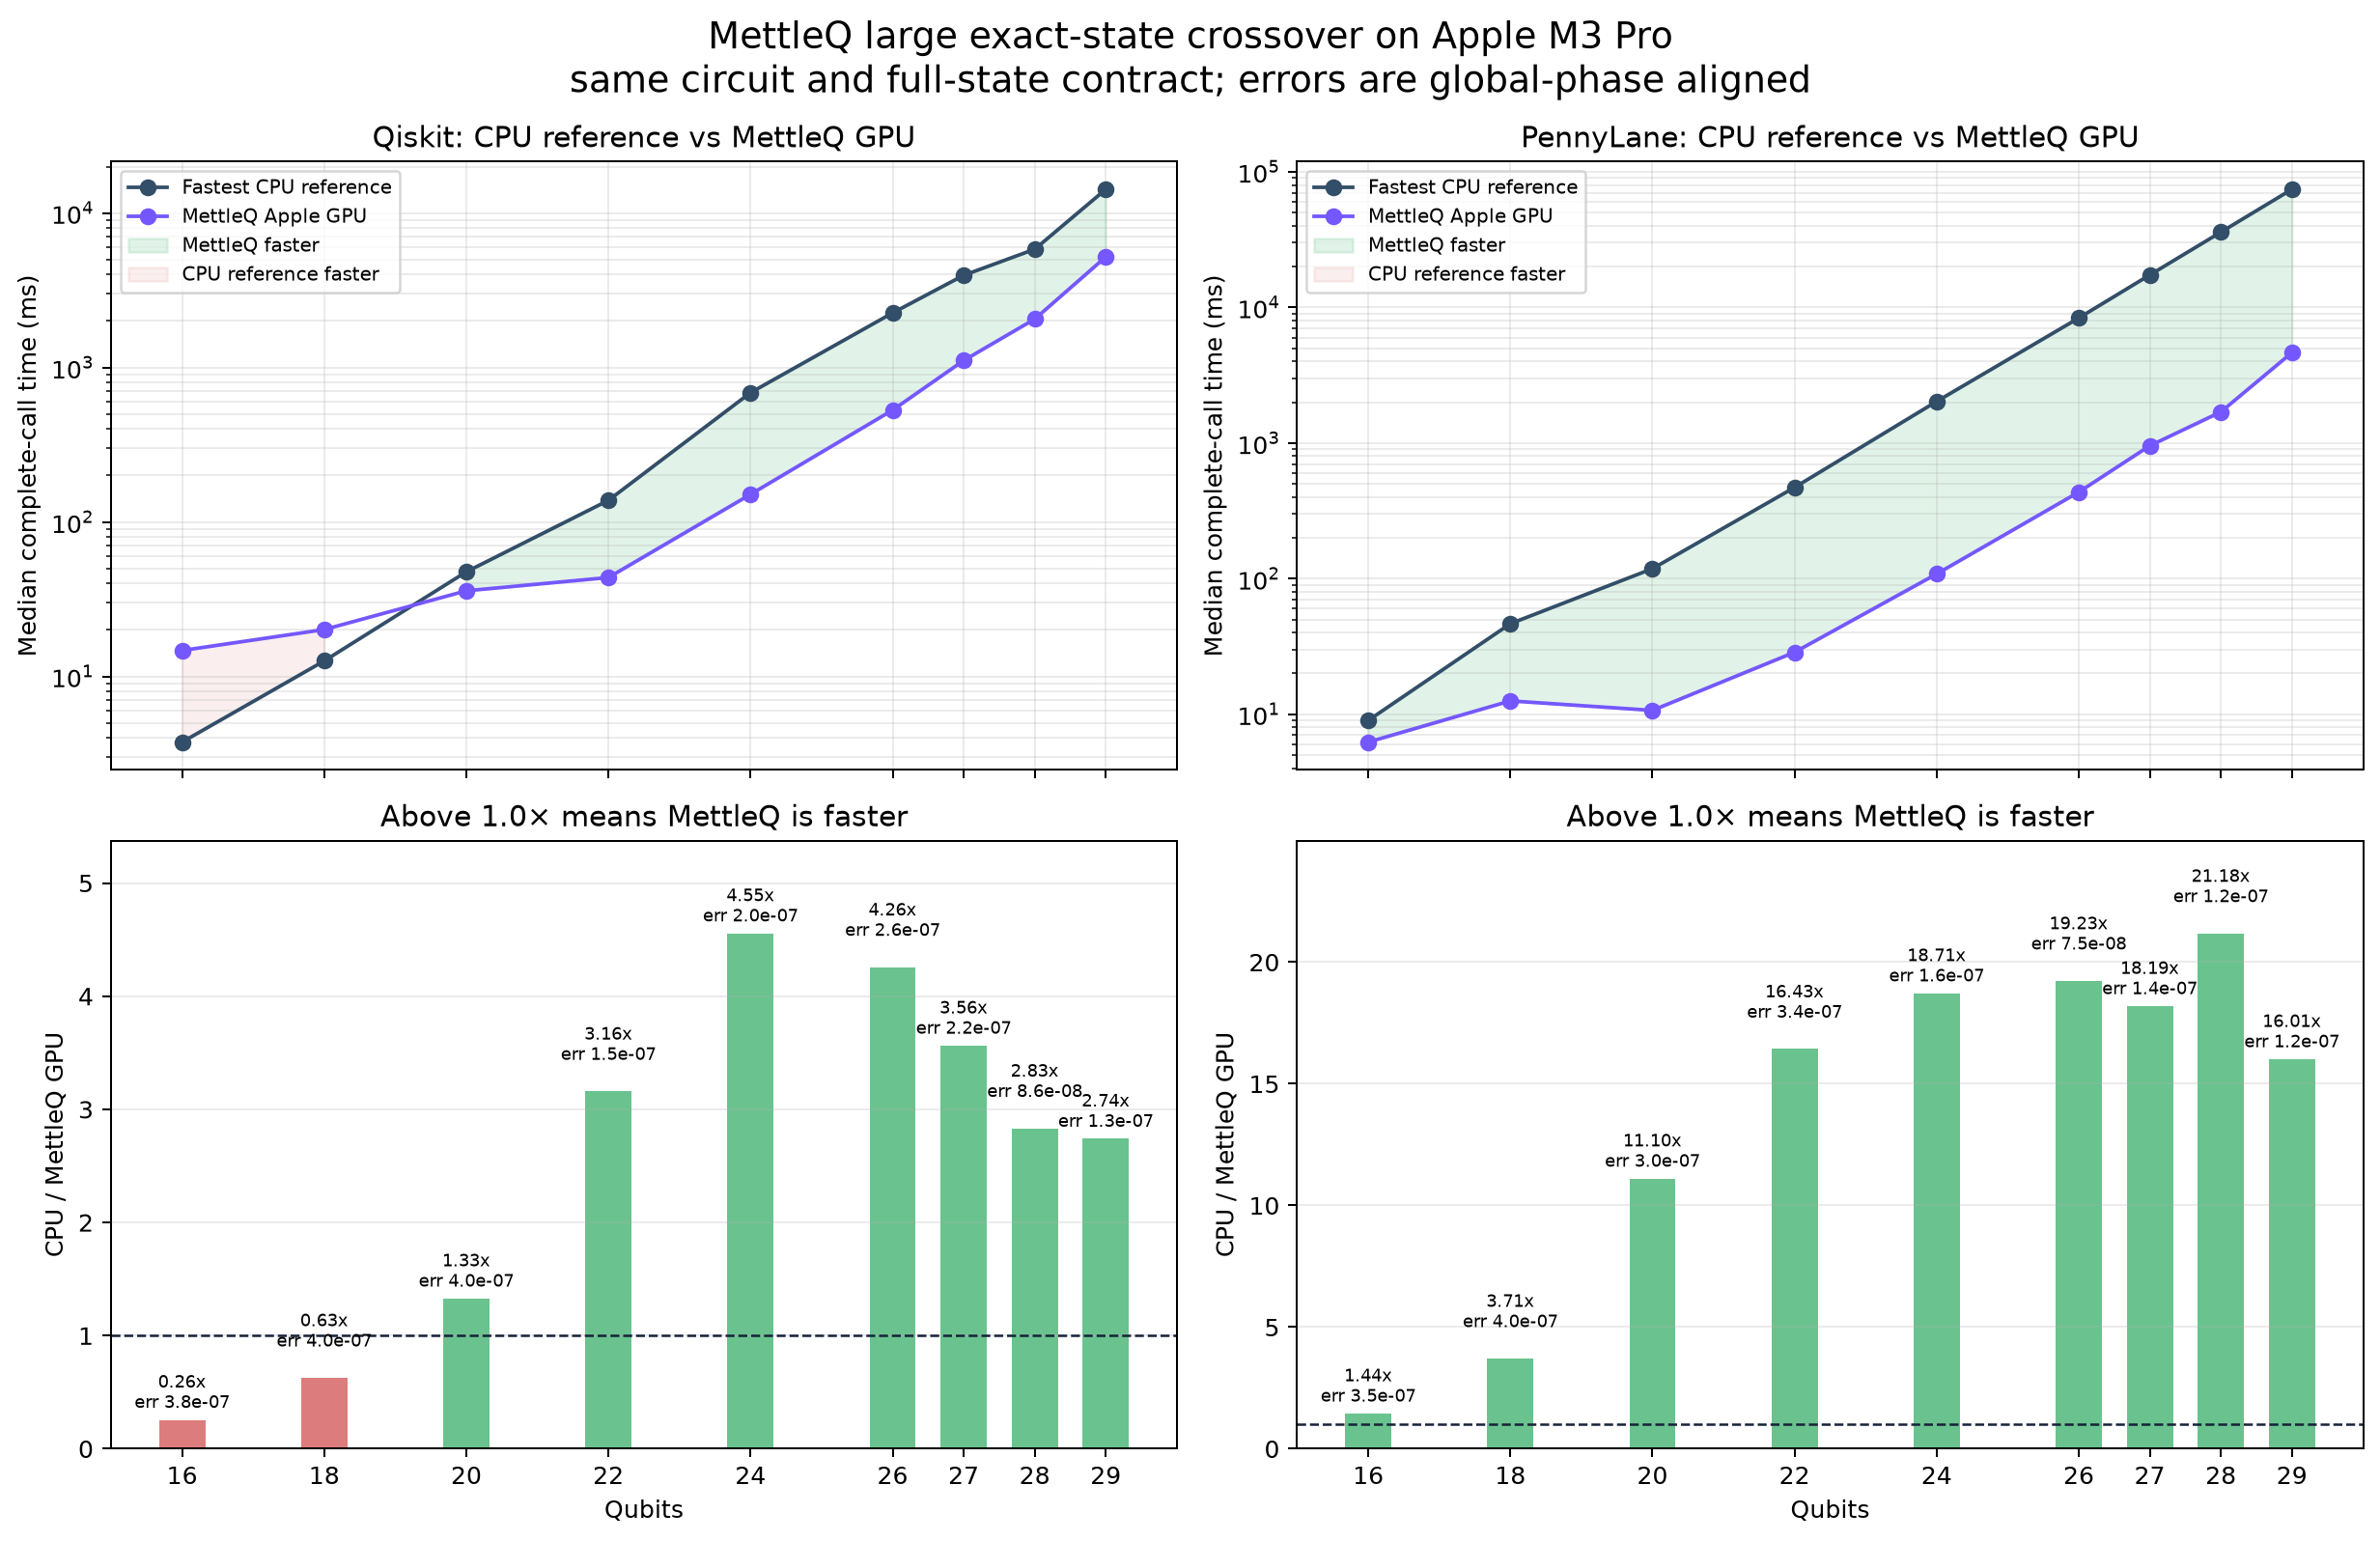

In [4]:
display(Image(filename=str(RUN / "sdk_cpu_gpu_crossover.png")))

## What the measurements say

- Against Qiskit Aer, MettleQ crosses over around 20 qubits and is 2.74–4.55×
  faster from 22 through the largest admitted 29-qubit full-state run.
- Against PennyLane Lightning, MettleQ is 16.0–21.2× faster from 22 through
  29 qubits in the clean rerun.
- Aer MPS is slower for this contract because returning a complete dense
  statevector costs exponential time and memory, eliminating the principal
  reason to use an MPS. MPS should instead be benchmarked with bounded
  observables or samples on low-entanglement circuits.
- Qiskit's ASAP serialization originally hid legal layers. The current engine
  reconstructs the per-wire dependency DAG, preserves every same-wire order,
  and fuses ready disjoint U2/U3 and affine operations into native Metal passes.
  Generic one-qubit layers now apply four different matrices per radix-16
  traversal instead of only two, reducing full-state memory traffic.
- The 30-qubit full-state comparison is a recorded safety refusal, not an
  attempted allocation.

## Why many tutorial rows say `Exact? False`

That column asks whether two outputs are bit-for-bit identical. It is stricter
than mathematical correctness. MettleQ's Apple GPU path commonly uses
complex64, whereas CPU references use complex128, so differences around
`1e-7` are normal. Finite-shot simulators also use independent random streams
and should be checked by distribution distance, not identical samples.

The project therefore records both facts: exact equality for transparency and
an explicit numerical/statistical acceptance test for correctness.

In [5]:
audit = json.loads((ROOT / "tutorials/correctness_audit.json").read_text())
summary = {key: audit[key] for key in (
    "all_passed", "notebooks", "bit_for_bit_matches",
    "tolerance_validated_matches", "largest_primary_error_over_tolerance",
)}
summary

{'all_passed': True,
 'notebooks': 29,
 'bit_for_bit_matches': 9,
 'tolerance_validated_matches': 20,
 'largest_primary_error_over_tolerance': 0.40726740975956705}

## Reproduce the expensive benchmark

The notebook reads frozen evidence so opening it does not allocate multi-GB
states. To rerun the measurement on the current Mac:

```bash
PYTHONPATH=src caffeinate -i .venv/bin/python \
  tools/benchmark_sdk_crossover_large.py \
  --widths 16,18,20,22,24,26,27,28,29,30 \
  --depth 3 --warmups 1 --repeats 3 \
  --max-qiskit-mps-width 22 --accuracy-atol 5e-6 \
  --output-dir bench/runs/sdk-crossover-large
```

The `caffeinate` process exits automatically when Python finishes.

## Practical conclusion

For this machine and exact full-state circuit family, a sensible policy is:

- prefer a CPU path for small circuits;
- prefer MettleQ GPU over `lightning.qubit` once the measured workload clears
  its small-circuit overhead;
- prefer MettleQ GPU over Aer for this full-state family from the measured
  20-qubit crossover, while retaining Aer as the CPU fallback and baseline; and
- choose MPS based on entanglement and output contract, not qubit count alone.

These are measured policy inputs, not permanent universal thresholds. Different
circuits, Mac models, precisions, and requested outputs require recalibration.